# Demand Estimation and Market Analysis: Air Fryers

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

In [4]:
#grab the file!
#!wget https://github.com/SafaaMahbub/ML_Final_Project/blob/main/air_fryers_clean_brand_year.csv
# DONT USE THIS, for some reason the file brakes, just download and upload it into your directory.
# will try smtg else later lol

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [5]:
#Some import statemnts for all the people who wanna do stuff
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [6]:
#1
df = pd.read_csv("/content/air_fryers_clean_brand_year.csv")

print(df.shape)


(50, 15)


In [7]:
unique_values = df['brand'].unique() #see unique values
print(unique_values) #there is 10 Woop!!!

['chefman' 'cosori' 'cuisinart' 'dash' 'gowise usa' 'instant_pot' 'ninja'
 'nuwave' 'oster' 'ultrean']


In [8]:
unique_values = df['year'].unique() #see unique values
print(unique_values) #It covers 2019 - 2023!!

[2019 2020 2021 2022 2023]


#1.
I verified that the 10 brands are there and it contains all years by looking at the unique values in those columns.

In [9]:
print(df.head()) #see columns and years all togeher

     category  year       brand  purchase_count  product_count   avg_price  \
0  air_fryers  2019     chefman            1146             10   72.963695   
1  air_fryers  2019      cosori              11              2  159.990000   
2  air_fryers  2019   cuisinart            1616             22  229.465274   
3  air_fryers  2019        dash            3011             19   55.176333   
4  air_fryers  2019  gowise usa            4405             45   83.575551   

   avg_rating  compact_share  dual_basket_share  oven_style_share  \
0    4.434119       1.000000                0.0          0.780977   
1    4.581818       1.000000                0.0          0.090909   
2    4.481312       0.993812                0.0          0.889851   
3    4.390767       1.000000                0.0          0.973431   
4    4.552259       0.999773                0.0          0.129398   

   rotisserie_share  window_share  market_purchases  brand_share  \
0          0.243455      0.184119             15

Text(0.5, 0, 'Year')

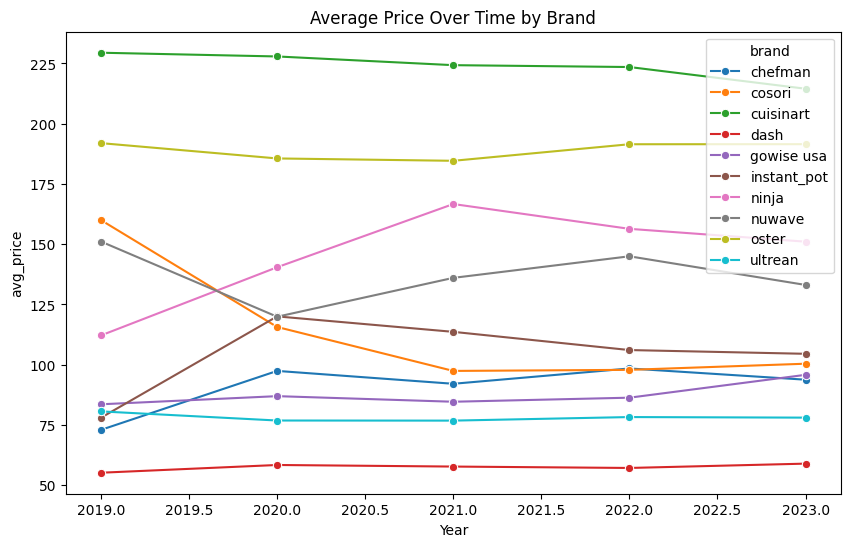

In [10]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='avg_price', hue='brand', marker='o')
plt.title('Average Price Over Time by Brand')
plt.xlabel('Year')

Text(0.5, 0, 'Year')

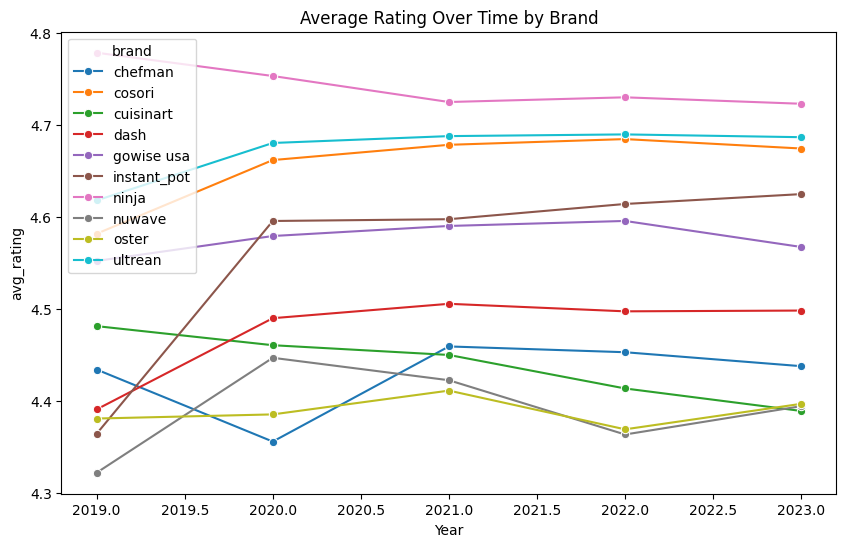

In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='avg_rating', hue='brand', marker='o')
plt.title('Average Rating Over Time by Brand')
plt.xlabel('Year')

Text(0.5, 0, 'Year')

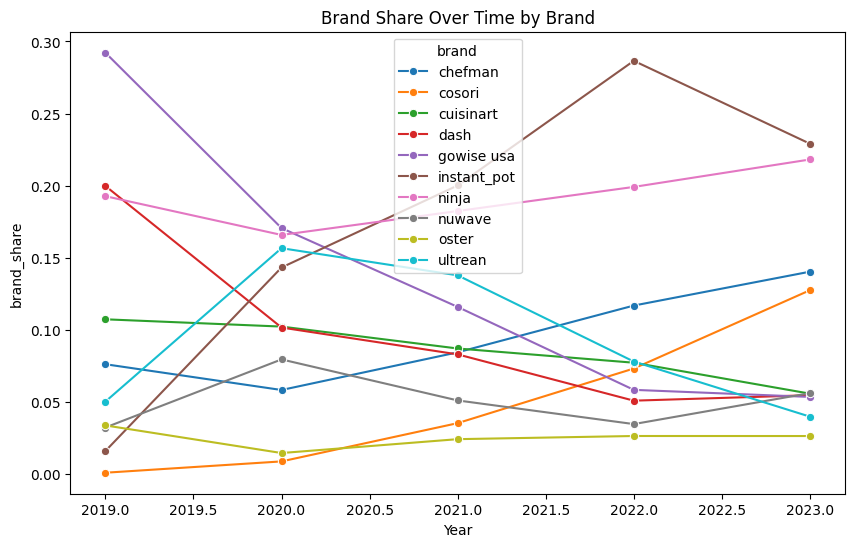

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='brand_share', hue='brand', marker='o')
plt.title('Brand Share Over Time by Brand')
plt.xlabel('Year')

#2
The three plots are above.

Text(0.5, 0, 'Year')

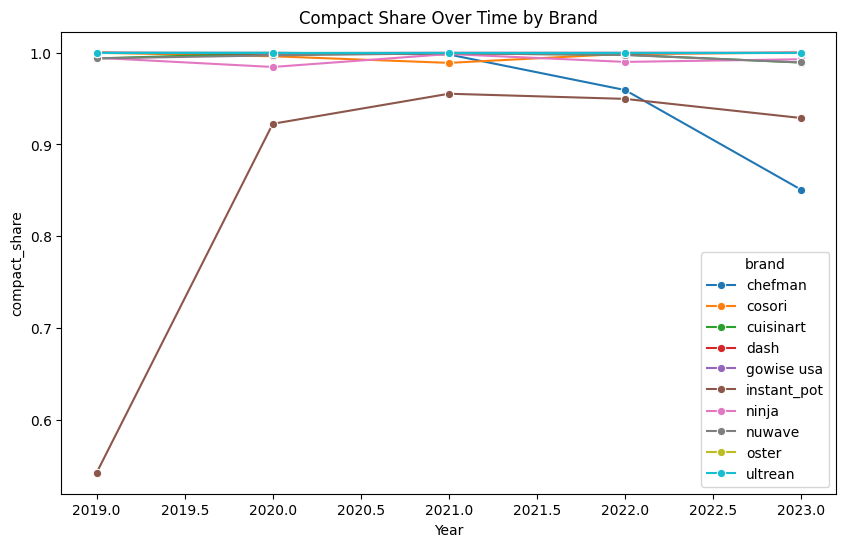

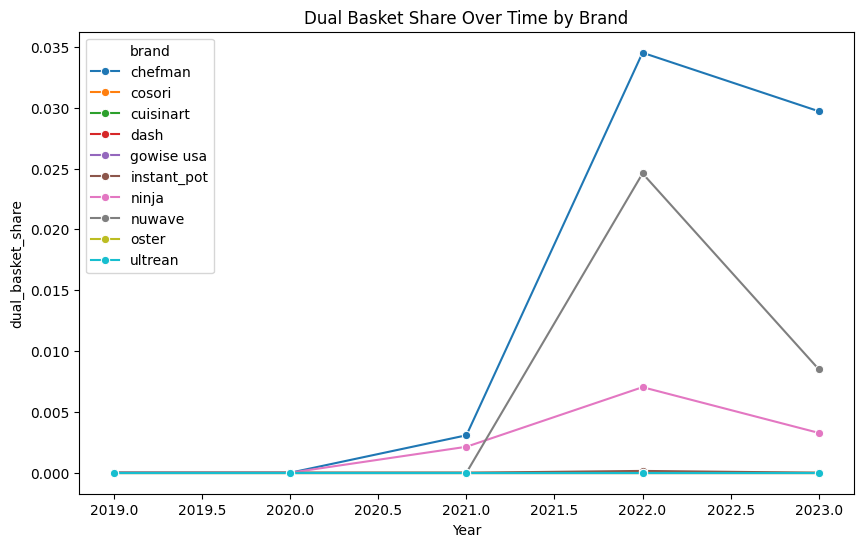

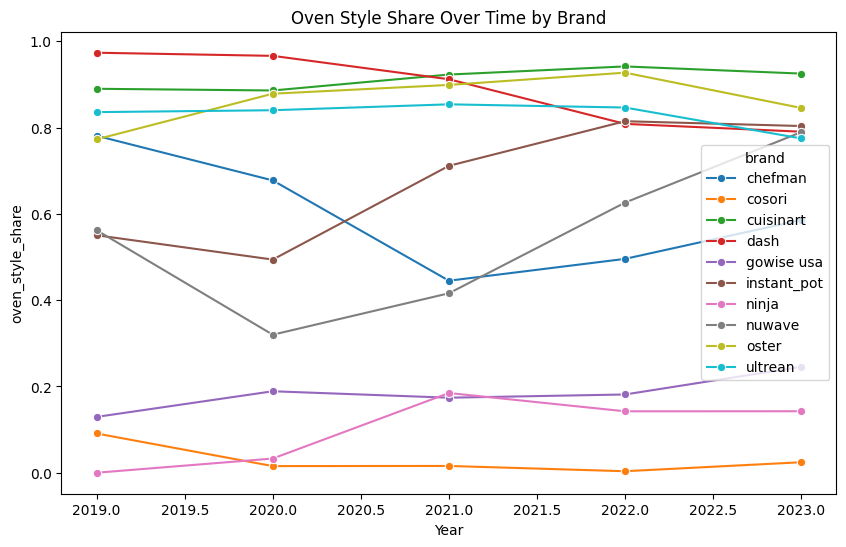

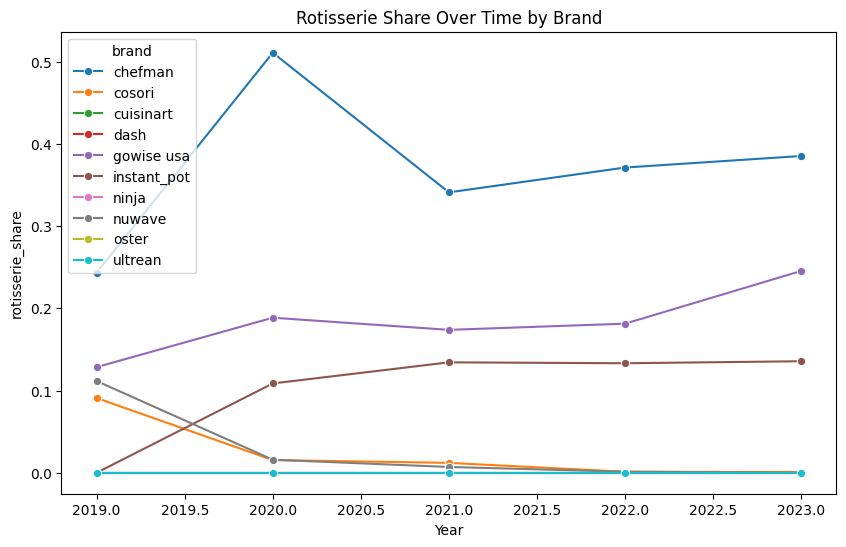

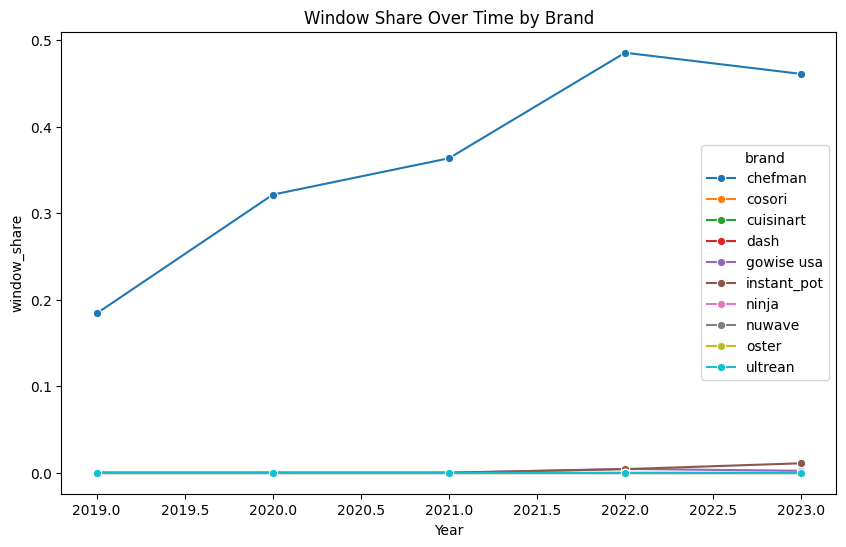

In [13]:
#plot the differnt attrubites over the years
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='compact_share', hue='brand', marker='o')
plt.title('Compact Share Over Time by Brand')
plt.xlabel('Year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='dual_basket_share', hue='brand', marker='o')
plt.title('Dual Basket Share Over Time by Brand')
plt.xlabel('Year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='oven_style_share', hue='brand', marker='o')
plt.title('Oven Style Share Over Time by Brand')
plt.xlabel('Year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='rotisserie_share', hue='brand', marker='o')
plt.title('Rotisserie Share Over Time by Brand')
plt.xlabel('Year')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='window_share', hue='brand', marker='o')
plt.title('Window Share Over Time by Brand')
plt.xlabel('Year')

#3
1. Looking at the plots above, the most commen trait seems to be compact and oven style.

2. The rarer traits seems to be window, rotisserie and dual ovan.

3. Yes, specialziation is evident in some brands. For example, chefman seems to hold a monoploy in the window share. This has lasted across 2019 to 2023. It also leads in dual basket, but its slowly having more competition.

#4 Summery
Prices over time for the brands seem to be very stagant, meaning most brands have not made large alterations to the costs of there products. The most expesnive brand seems to be cuisinart, followed by oster, ninja, and nuwave. The rest are realtivily close, with dash being the lowest. At first gowise_usa had the higest in 2019, but it has fallen greatly. The two new share leaders being ninja and instant_pot. The next two are chefman and sosori, with the rest being very simlir.

Evidently a top brand (gowise_usa) in 2019 falling almost 20-25 percent shows violatility. Instant pot and ninja are new market leaders since 2020, with the next two spots being regualrly changing throughout the years. Cosori though has had a good substuational raise over time.

## 2. Demand Estimation

We will estimate a logit-style demand model using linear regression. The model is:

$$
\log(s_{bt}) = \alpha_0 + \alpha_t + \gamma_b + \beta_{price}p_{bt} + \beta_{rating}r_{bt} + \sum_{\ell=1}^L \beta_\ell x_{bt\ell} + \epsilon_{bt}.
$$

Here:

- $b$ indexes brands
- $t$ indexes years
- $s_{bt}$ is `brand_share`
- $p_{bt}$ is `avg_price`
- $r_{bt}$ is `avg_rating`
- $x_{bt\ell}$ are the product characteristics
- $\alpha_t$ are year dummy coefficients
- $\gamma_b$ are brand dummy coefficients
- $\beta_{price}$ is **one constant price coefficient**, shared by all brands and all years

That last point matters: do **not** estimate a different price coefficient for every brand-year. We do not have enough information for that, and it would make the cost calculation impossible to interpret.

Use `pd.get_dummies(..., drop_first=True)` for brand and year dummies. The dropped brand and dropped year become the reference categories, so all dummy coefficients are interpreted relative to those omitted categories.

Questions:

1. What is the estimated price coefficient, $\hat{\beta}_{price}$?
2. Is it negative? Why is that important?
3. Which product features are associated with higher demand?
4. Which brand dummy coefficients are largest? Remember that these are interpreted relative to the dropped brand.
5. Which year dummy coefficients are largest? Remember that these are interpreted relative to the dropped year.
6. What is the model's $R^2$?

This part of the work is the **data scientist** role: turning the cleaned data into a model that can be used for prediction and interpretation.

In [14]:
y= df["log_brand_share"]
feature_cols = ["compact_share","dual_basket_share","oven_style_share","rotisserie_share","window_share"]
brand_dummies = pd.get_dummies(df["brand"], drop_first=True)
year_dummies = pd.get_dummies(df["year"].astype(str), drop_first=True)

X = pd.concat(
    [df[["avg_price", "avg_rating"] + feature_cols],
    brand_dummies,
    year_dummies],
    axis=1,)


model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)


coef_table = pd.DataFrame(
    {
        "feature": X.columns,
        "coefficient": model.coef_,
    })


print(f"R^2: {r2}")
coef_table

R^2: 0.763453950091436


,feature,coefficient
0,avg_price,-0.037668
1,avg_rating,0.287517
2,compact_share,9.815304
3,dual_basket_share,-9.509686
4,oven_style_share,1.941774
5,rotisserie_share,-5.674054
6,window_share,12.880298
7,cosori,2.551946
8,cuisinart,6.422436
9,dash,0.176655


1. the estimated price coefficient is -0.037668
2. Yes, the price coefficient is negative because that means that the brand share goes down as the price goes up.
3. dual_basket share and rotisserie share

## 3. Strategy: Costs, Markups, and Profit

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.

Questions:

1. What are the average unit costs and markups for each brand over the years?
2. Are any inferred unit costs negative? If so, what might that mean?
3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.
5. Which brands have the highest share-weighted average profit?

This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.

Q3 Response

In [16]:
beta_price = -0.037668
df['demand_slope'] = beta_price * df['brand_share'] * (1 - df['brand_share'])
df['unit_cost'] = df['avg_price'] + (df['brand_share'] / df['demand_slope'])
df['markup'] = df['avg_price'] - df['unit_cost']
df['profit_margin_pct'] = (df['markup'] / df['avg_price']) * 100
df['average_profit'] = df['brand_share'] * df['markup']

1.

In [17]:
brand_costs_markups = df.groupby('brand')[['unit_cost', 'markup']].mean().reset_index()
print("Average unit costs and markups for each brand:")
print(brand_costs_markups)

Average unit costs and markups for each brand:
         brand   unit_cost     markup
0      chefman   61.569736  29.368675
1       cosori   86.283579  27.984371
2    cuisinart  194.896386  29.050707
3         dash   27.936850  29.542077
4   gowise usa   56.301327  31.153454
5  instant_pot   71.903419  32.557934
6        ninja  112.488773  32.853768
7       nuwave  109.053806  27.970578
8        oster  161.805219  27.226064
9      ultrean   48.786035  29.328571


2.

In [18]:
negative_unit_costs = df[df['unit_cost'] < 0]
if not negative_unit_costs.empty:
    print("Brands with negative inferred unit costs:")
    print(negative_unit_costs[['brand', 'year', 'unit_cost']])
    print("\nNegative unit costs can indicate a misspecification in the demand model or issues with the underlying data. It suggests that the price is lower than what the model predicts as the marginal cost, given the observed market share. This might happen if the linear regression model doesn't perfectly capture the demand elasticity or if there are factors not accounted for in the model that influence pricing and market share.")
else:
    print("No negative inferred unit costs were found.")

No negative inferred unit costs were found.


3.

Brands with the highest average unit costs (descending order):
         brand   unit_cost     markup
2    cuisinart  194.896386  29.050707
8        oster  161.805219  27.226064
6        ninja  112.488773  32.853768
7       nuwave  109.053806  27.970578
1       cosori   86.283579  27.984371
5  instant_pot   71.903419  32.557934
0      chefman   61.569736  29.368675
4   gowise usa   56.301327  31.153454
9      ultrean   48.786035  29.328571
3         dash   27.936850  29.542077

Average unit costs and average ratings by brand:
         brand   unit_cost     markup  avg_rating
2    cuisinart  194.896386  29.050707    4.438892
8        oster  161.805219  27.226064    4.388653
6        ninja  112.488773  32.853768    4.742064
7       nuwave  109.053806  27.970578    4.389798
1       cosori   86.283579  27.984371    4.656292
5  instant_pot   71.903419  32.557934    4.559323
0      chefman   61.569736  29.368675    4.427966
4   gowise usa   56.301327  31.153454    4.576990
9      ultrean   48

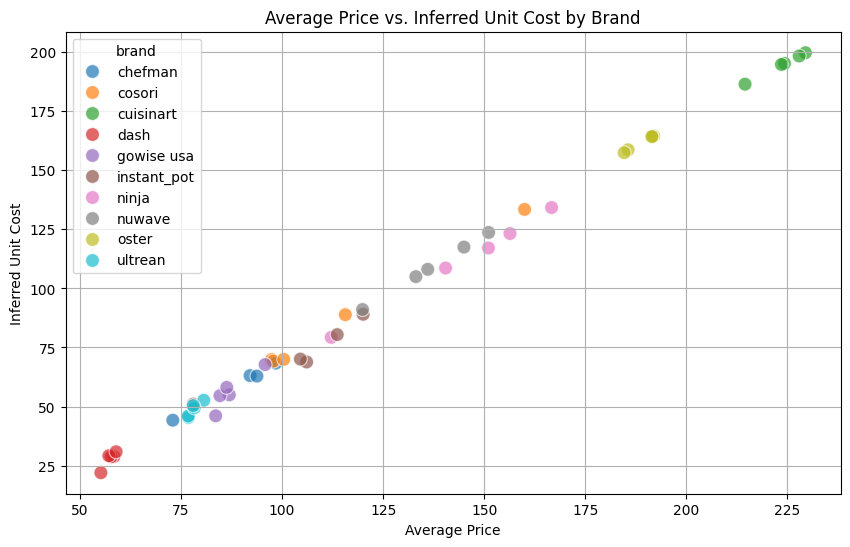

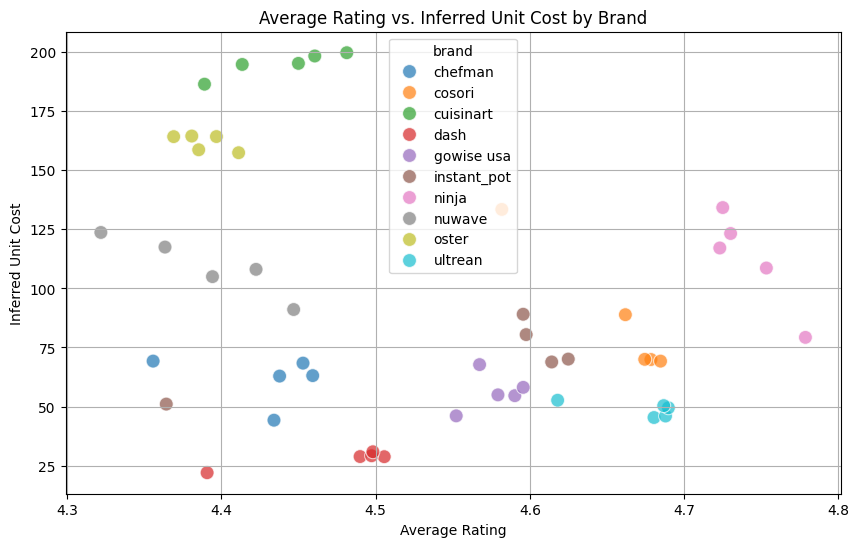

In [19]:
print("Brands with the highest average unit costs (descending order):")
print(brand_costs_markups.sort_values(by='unit_cost', ascending=False))

avg_ratings_by_brand = df.groupby('brand')['avg_rating'].mean().reset_index()
brand_analysis = pd.merge(brand_costs_markups, avg_ratings_by_brand, on='brand')

print("\nAverage unit costs and average ratings by brand:")
print(brand_analysis.sort_values(by='unit_cost', ascending=False))

#scatter plot of Price vs. Unit Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_price', y='unit_cost', hue='brand', s=100, alpha=0.7)
plt.title('Average Price vs. Inferred Unit Cost by Brand')
plt.xlabel('Average Price')
plt.ylabel('Inferred Unit Cost')
plt.grid(True)
plt.show()

#scatter plot of Average Rating vs. Unit Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_rating', y='unit_cost', hue='brand', s=100, alpha=0.7)
plt.title('Average Rating vs. Inferred Unit Cost by Brand')
plt.xlabel('Average Rating')
plt.ylabel('Inferred Unit Cost')
plt.grid(True)
plt.show()

4 and 5

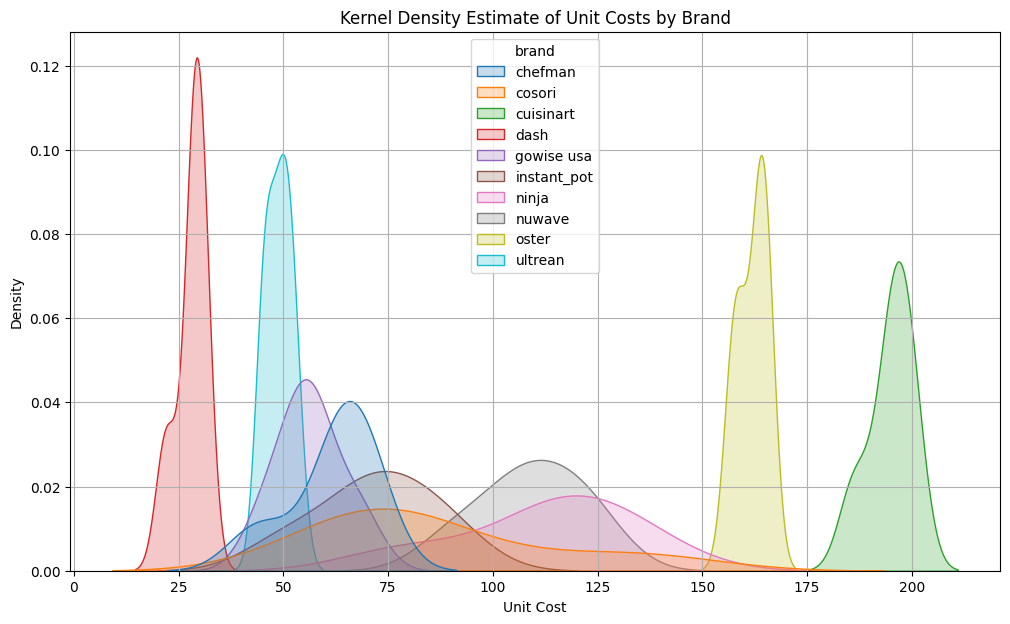

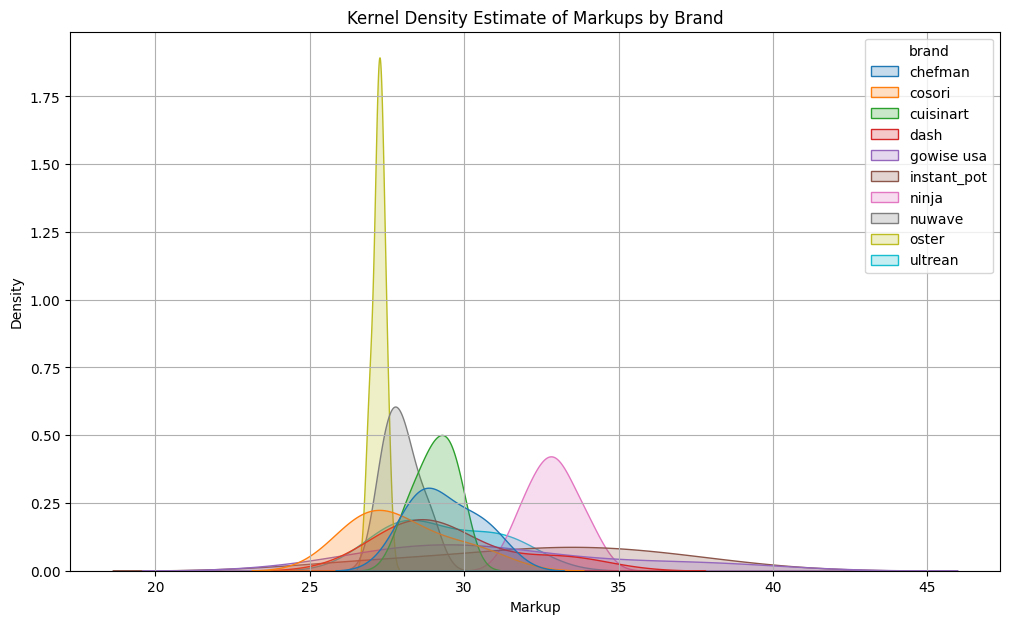

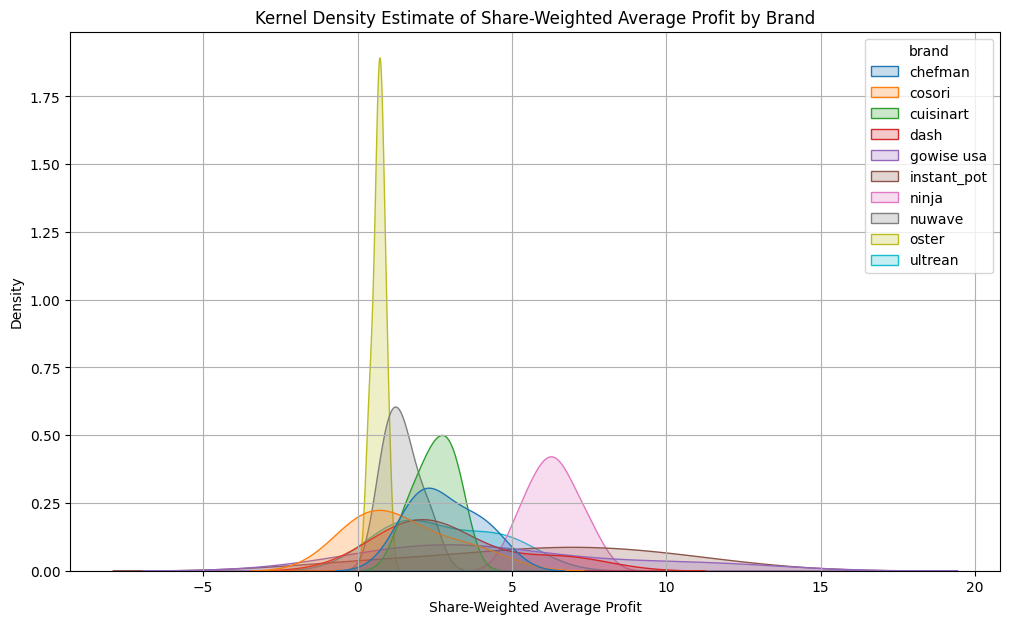


Brands with the highest average share-weighted profit (descending order):
         brand  average_profit
0        ninja        6.306035
1  instant_pot        6.010201
2   gowise usa        4.605721
3         dash        2.994344
4      chefman        2.820942
5      ultrean        2.780838
6    cuisinart        2.502974
7       cosori        1.436638
8       nuwave        1.422845
9        oster        0.678332


In [20]:
#Kernel Density Plot for Unit Costs
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='unit_cost', hue='brand', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Unit Costs by Brand')
plt.xlabel('Unit Cost')
plt.ylabel('Density')
plt.grid(True)
plt.show()

#Kernel Density Plot for Markups
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='markup', hue='brand', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Markups by Brand')
plt.xlabel('Markup')
plt.ylabel('Density')
plt.grid(True)
plt.show()

#Kernel Density Plot for Average Profit
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='average_profit', hue='brand', fill=True, common_norm=False)
plt.title('Kernel Density Estimate of Share-Weighted Average Profit by Brand')
plt.xlabel('Share-Weighted Average Profit')
plt.ylabel('Density')
plt.grid(True)
plt.show()

#5.
print("\nBrands with the highest average share-weighted profit (descending order):")
print(df.groupby('brand')['average_profit'].mean().sort_values(ascending=False).reset_index())

## 4. Results

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.